In [ ]:

import cv2, json, joblib, torch, timm, gc, random
import numpy as np
from pathlib import Path
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
ROOT = Path(r"C:\Users\hugop\OneDrive\Bureau\ML_project")
DATA_DIR = ROOT / "data"
MODEL_PATH = ROOT / r"models\deep\vit_pca256_rf.joblib"   # <- RF (peux changer pour histgb)
LABELS_PATH = ROOT / "labels.json"
OUT_DIR = ROOT / r"notebook\outputs_detection"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"


c:\Users\hugop\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

def largest_bbox(mask: np.ndarray):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)
    return x,y,w,h
def pad_bbox(x,y,w,h, W,H, ratio=0.12):
    px = int(w*ratio); py = int(h*ratio)
    x0 = max(0, x - px); y0 = max(0, y - py)
    x1 = min(W, x + w + px); y1 = min(H, y + h + py)
    return x0, y0, x1-x0, y1-y0
def segment_foreground(img_bgr: np.ndarray):
    """Retourne (roi_bgr, (x,y,w,h)) ; essaie seuil + morpho puis fallback GrabCut."""
    H, W = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2]
    _, th = cv2.threshold(v, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((5,5), np.uint8), iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((9,9), np.uint8), iterations=1)
    bb = largest_bbox(th)
    if bb is not None:
        x,y,w,h = bb
        if w*h > 0.02*W*H:  # évite poussières
            x,y,w,h = pad_bbox(x,y,w,h,W,H,ratio=0.15)
            roi = img_bgr[y:y+h, x:x+w].copy()
            return roi, (x,y,w,h), th
    rect = (int(0.08*W), int(0.08*H), int(0.84*W), int(0.84*H))
    mask = np.zeros((H,W), np.uint8)
    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)
    cv2.grabCut(img_bgr, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
    mask2 = np.where((mask==2) | (mask==0), 0, 255).astype('uint8')
    bb = largest_bbox(mask2)
    if bb is None:
    
        return img_bgr.copy(), (0,0,W,H), mask2
    x,y,w,h = pad_bbox(*bb, W,H, ratio=0.10)
    roi = img_bgr[y:y+h, x:x+w].copy()
    return roi, (x,y,w,h), mask2


In [ ]:

def classify_image(path: Path, save_vis=True):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Image illisible: {path}")
    roi, (x,y,w,h), mask = segment_foreground(img)
    feats = vit_feats(roi)
    pred = int(clf.predict(feats)[0])
    label = idx_to_class[pred]
    vis = img.copy()
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 3)
    cv2.putText(vis, label, (x+10, y-10 if y>25 else y+h+30),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,0), 3)
    if save_vis:
        out_path = OUT_DIR / f"{path.parent.name}__{path.stem}__{label}.jpg"
        cv2.imwrite(str(out_path), vis)
    return label, vis, roi, mask
samples = []
for c in class_names:
    imgs = sorted((DATA_DIR/c).glob("*.*"))[:3]
    samples += imgs

for p in samples:
    lbl, vis, roi, mask = classify_image(p, save_vis=True)
print(f"Visualisations sauvegardées dans: {OUT_DIR}")


Visualisations sauvegardées dans: C:\Users\hugop\OneDrive\Bureau\ML_project\notebook\outputs_detection


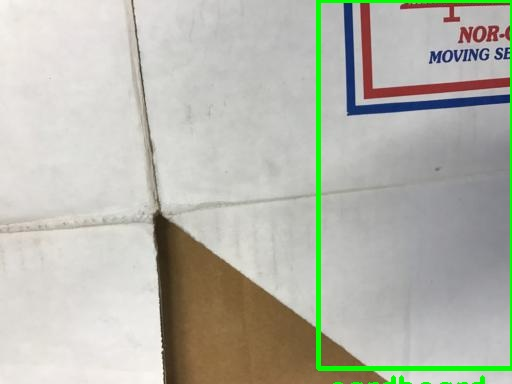

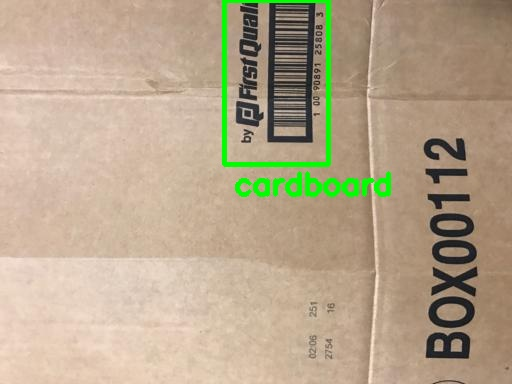

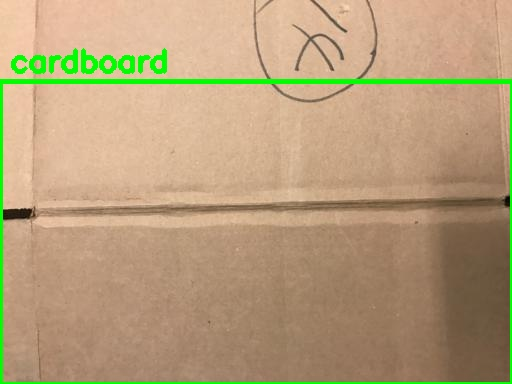

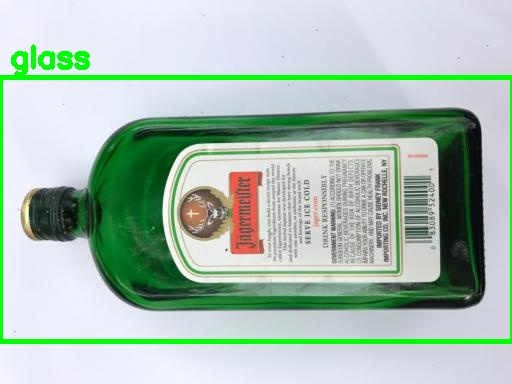

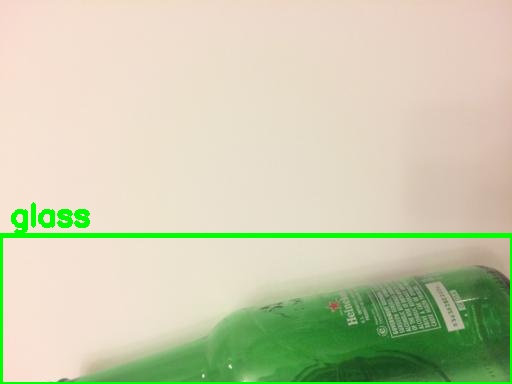

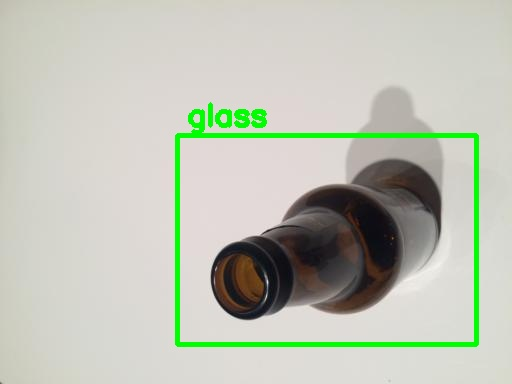

In [6]:
from IPython.display import Image as IPyImage, display
for p in list(OUT_DIR.glob("*.jpg"))[:6]:
    display(IPyImage(filename=str(p)))


In [ ]:

val_paths, y_true, y_pred = [], [], []
for c in class_names:
    all_imgs = sorted((DATA_DIR/c).glob("*.*"))
    k = max(1, int(0.2*len(all_imgs)))
    for p in all_imgs[-k:]:  # prends 20% de la fin comme pseudo-val
        val_paths.append(p)
        y_true.append(class_to_idx[c])
for p in val_paths:
    pred_label, _, _, _ = classify_image(p, save_vis=False)
    y_pred.append(class_to_idx[pred_label])
y_true = np.array(y_true); y_pred = np.array(y_pred)
acc = (y_true == y_pred).mean()
print(f"Validation (split simple) — Accuracy: {acc:.4f}")
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


Validation (split simple) — Accuracy: 0.8827
              precision    recall  f1-score   support

   cardboard      0.973     0.912     0.942        80
       glass      0.950     0.950     0.950       100
       metal      0.963     0.939     0.951        82
       paper      0.758     0.958     0.846       118
     plastic      0.874     0.792     0.831        96
       trash      0.833     0.370     0.513        27

    accuracy                          0.883       503
   macro avg      0.892     0.820     0.839       503
weighted avg      0.890     0.883     0.878       503



In [ ]:
# expl
def batch_predict(paths, batch_size=32):
    feats_list, meta = [], []
    for p in paths:
        img = cv2.imread(str(p)); roi, bbox, _ = segment_foreground(img)
        feats_list.append(vit_feats(roi))  # 1 x D
        meta.append((p, bbox))
    X = np.vstack(feats_list)  # N x D
    preds = clf.predict(X)
    return preds, meta
